# CropGuard AI — 01 Exploratory Data Analysis
**NASTP Institute of Information Technology | AI335L — Deep Learning Lab | Spring 2026**

Covers:
1. Dataset inventory and class distribution
2. Representative sample images
3. RGB channel analysis
4. Blur/quality filtering (Laplacian variance)
5. PCA and t-SNE feature-space visualisation

**Key finding:** Potato Healthy class has only 152 images — a 12.6× imbalance vs the majority class (Tomato Late Blight, 1,909 images). This motivates the VAE augmentation in Phase 4.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src.utils import (
    TARGET_CLASSES, CLASS_DISPLAY, IMAGENET_MEAN, IMAGENET_STD,
    laplacian_variance, set_seed, BLUR_THRESH,
)

set_seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
PALETTE = plt.cm.tab10.colors
print('✅ Imports OK')

✅ Imports OK


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
DATA_ROOT = Path('../data/raw')       # ← Update to your PlantVillage colour folder
OUT_DIR   = Path('../data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED     = 42
N_SAMPLE = 80    # images per class for channel stats
N_VIS    = 120   # images per class for PCA/t-SNE
MLP_SIZE = 32    # flatten resolution for PCA features
PCA_N    = 50

print(f'Data root: {DATA_ROOT}')

Data root: ..\data\raw


## 1. Dataset Inventory

In [3]:
records = []
for cls_dir in sorted(DATA_ROOT.iterdir()):
    if cls_dir.is_dir() and cls_dir.name in TARGET_CLASSES:
        for img_path in cls_dir.glob('*'):
            if img_path.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                records.append({'path': str(img_path), 'class': cls_dir.name})

df = pd.DataFrame(records)
name_map = dict(zip(TARGET_CLASSES, CLASS_DISPLAY))
df['class_display'] = df['class'].map(name_map)
class_counts = df['class_display'].value_counts().reindex(CLASS_DISPLAY)

total = len(df)
imbalance = class_counts.max() / class_counts.min()

print(f'Total images  : {total:,}')
print(f'Classes       : {len(TARGET_CLASSES)}')
print(f'Imbalance ratio: {imbalance:.1f}× '
      f'({class_counts.idxmin()}: {class_counts.min():,} vs '
      f'{class_counts.idxmax()}: {class_counts.max():,})')
print()
for cls, cnt in class_counts.items():
    flag = '  ⚠️  CRITICAL' if cls == 'Potato Healthy' else ''
    print(f'  {cls:<30}  {cnt:5,}  ({cnt/total*100:5.2f}%){flag}')

Total images  : 11,481
Classes       : 10
Imbalance ratio: 12.6× (Potato Healthy: 152 vs Tomato Late Blight: 1,909)

  Tomato Early Blight             1,000  ( 8.71%)
  Tomato Late Blight              1,909  (16.63%)
  Tomato Healthy                  1,591  (13.86%)
  Potato Early Blight             1,000  ( 8.71%)
  Potato Late Blight              1,000  ( 8.71%)
  Potato Healthy                    152  ( 1.32%)  ⚠️  CRITICAL
  Pepper Bacterial Spot             997  ( 8.68%)
  Pepper Healthy                  1,478  (12.87%)
  Corn Common Rust                1,192  (10.38%)
  Corn Healthy                    1,162  (10.12%)


## 2. Class Distribution Visualisation

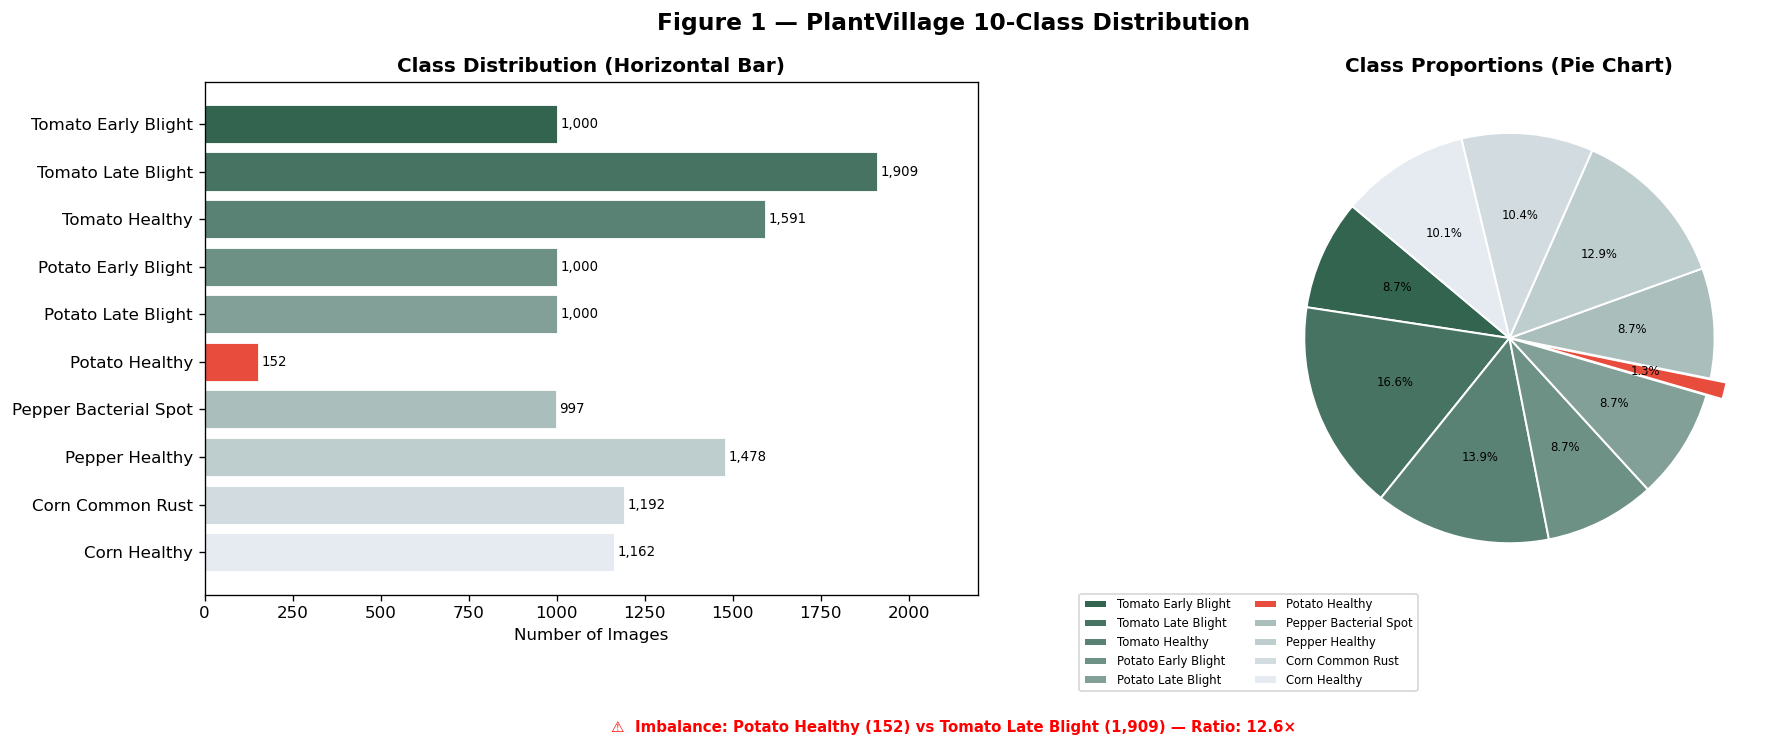

Saved to ..\data\processed/fig1_class_distribution.png


In [4]:
counts = [class_counts[c] for c in CLASS_DISPLAY]
colours = ['#e74c3c' if c == 'Potato Healthy'
           else f'#{(50+i*20)%255:02x}{(100+i*15)%255:02x}{(80+i*18)%255:02x}'
           for i, c in enumerate(CLASS_DISPLAY)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 1 — PlantVillage 10-Class Distribution', fontsize=14, fontweight='bold')

axes[0].barh(CLASS_DISPLAY, counts, color=colours, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Number of Images')
axes[0].set_title('Class Distribution (Horizontal Bar)', fontweight='bold')
for i, v in enumerate(counts):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontsize=8)
axes[0].set_xlim(0, max(counts) * 1.15)
axes[0].invert_yaxis()

explode = [0.08 if c == 'Potato Healthy' else 0.0 for c in CLASS_DISPLAY]
wedges, _, autotexts = axes[1].pie(
    counts, labels=None, colors=colours, explode=explode,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
for at in autotexts: at.set_fontsize(7)
axes[1].set_title('Class Proportions (Pie Chart)', fontweight='bold')
axes[1].legend(wedges, CLASS_DISPLAY, loc='lower left',
               bbox_to_anchor=(-0.35, -0.2), fontsize=7, ncol=2)

fig.text(0.5, -0.02,
         f'⚠️  Imbalance: Potato Healthy ({class_counts.min():,}) '
         f'vs Tomato Late Blight ({class_counts.max():,}) — Ratio: {imbalance:.1f}×',
         ha='center', fontsize=9, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved to {OUT_DIR}/fig1_class_distribution.png')

## 3. Representative Sample Images

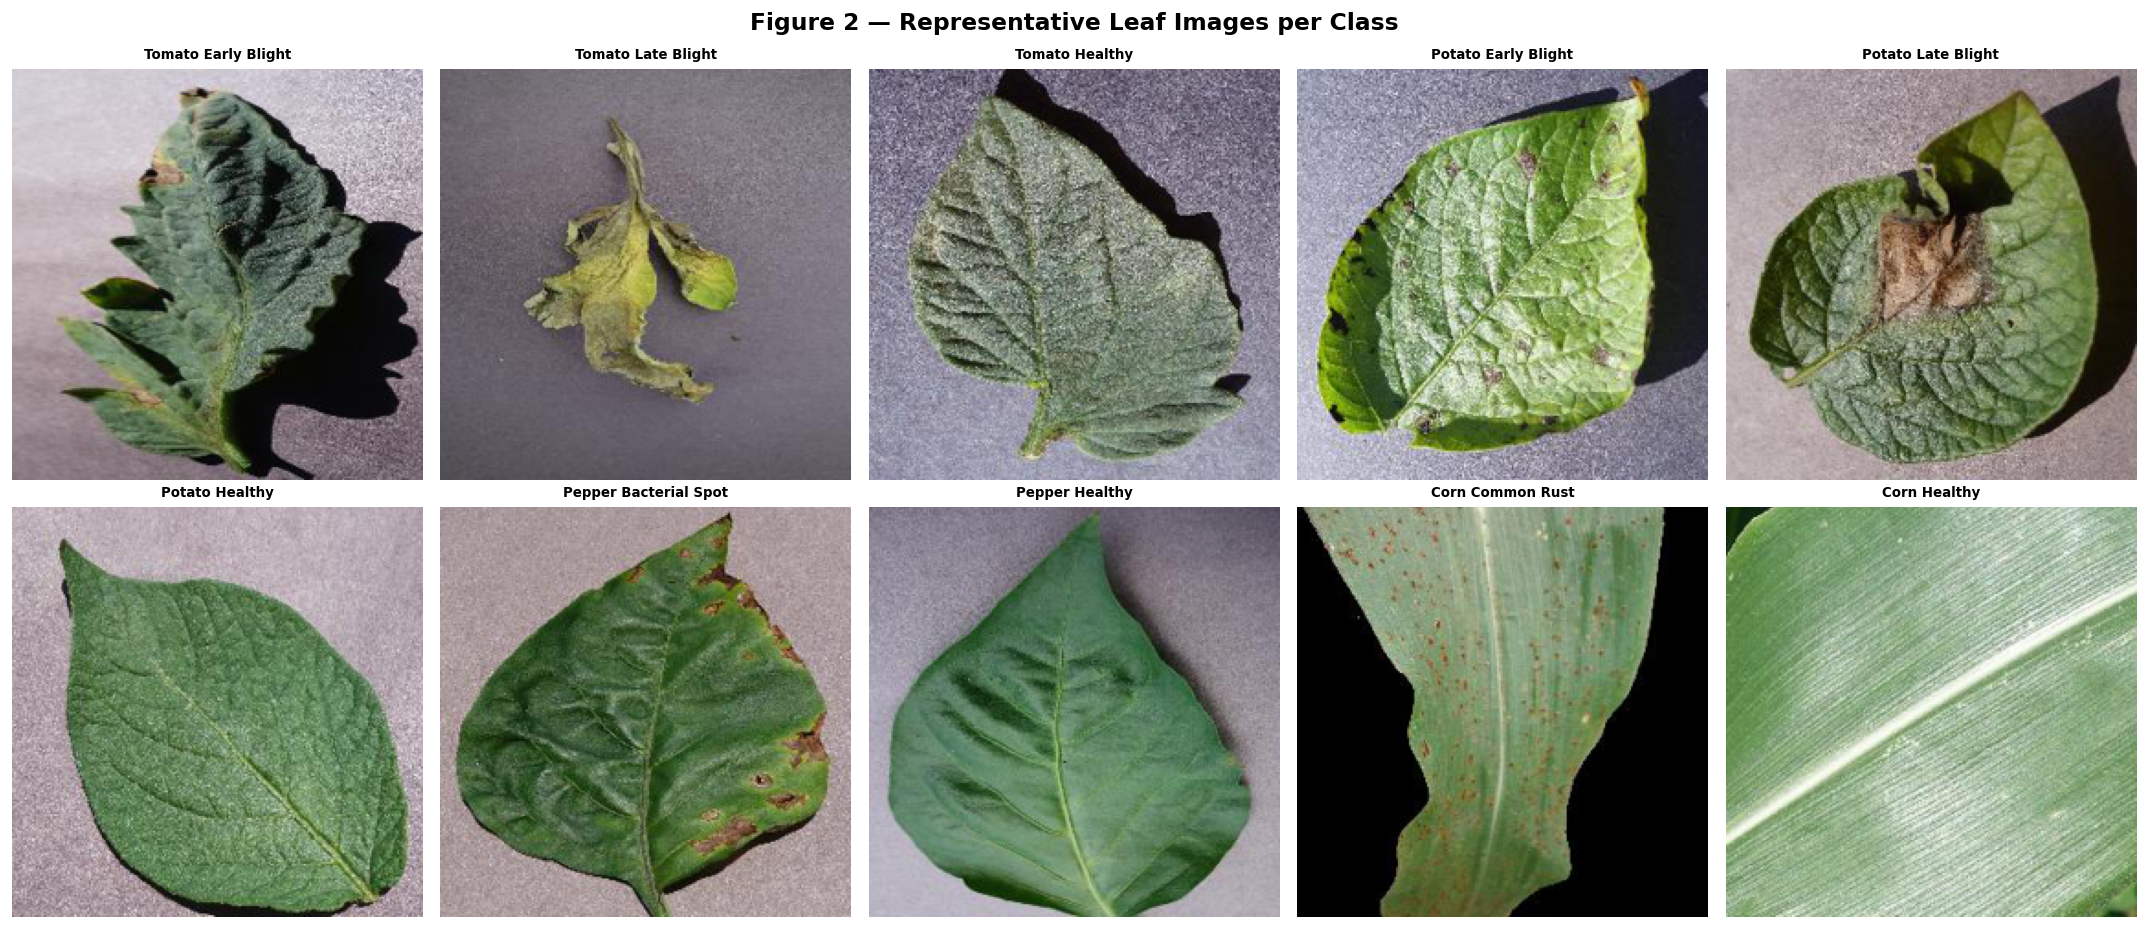

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Figure 2 — Representative Leaf Images per Class', fontsize=14, fontweight='bold')

for ax, cls_name, disp in zip(axes.flat, TARGET_CLASSES, CLASS_DISPLAY):
    cls_df = df[df['class'] == cls_name]
    img_path = cls_df.sample(1, random_state=SEED)['path'].values[0]
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    ax.imshow(img)
    ax.set_title(disp, fontsize=8, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_sample_images.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Quality Filter — Laplacian Variance

Applying quality filter (threshold = 50.0)...


Laplacian filter: 100%|██████████| 11481/11481 [06:05<00:00, 31.37it/s]


Original : 11,481
Removed  : 149  (1.3%)
Retained : 11,332


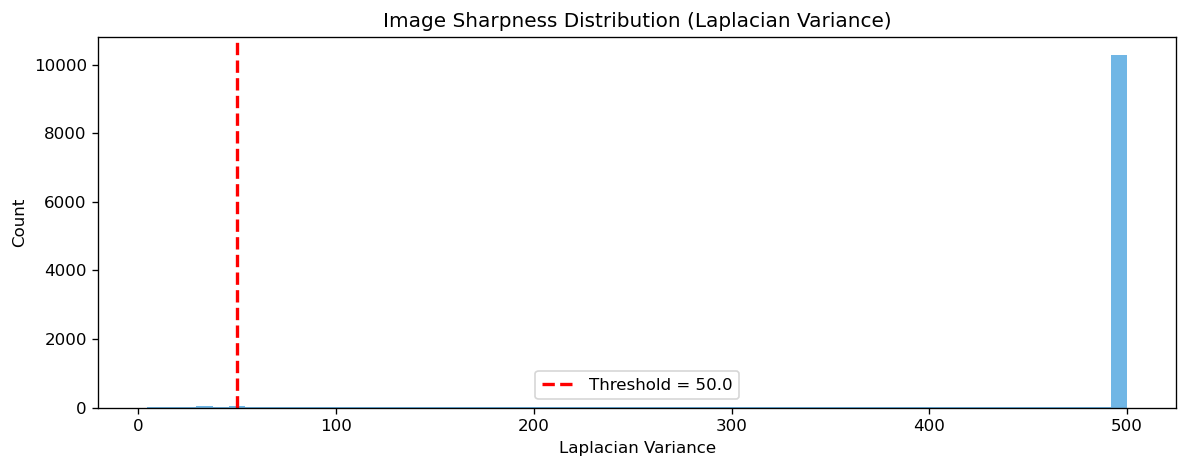

In [6]:
print(f'Applying quality filter (threshold = {BLUR_THRESH})...')
lap_scores = [laplacian_variance(p) for p in tqdm(df['path'], desc='Laplacian filter')]
df['laplacian'] = lap_scores
df_clean = df[df['laplacian'] >= BLUR_THRESH].copy()
removed = len(df) - len(df_clean)

print(f'Original : {len(df):,}')
print(f'Removed  : {removed:,}  ({removed/len(df)*100:.1f}%)')
print(f'Retained : {len(df_clean):,}')

# Distribution of Laplacian scores
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['laplacian'].clip(0, 500), bins=60, color='#3498db', alpha=0.7)
ax.axvline(BLUR_THRESH, color='red', linestyle='--', linewidth=2,
           label=f'Threshold = {BLUR_THRESH}')
ax.set_xlabel('Laplacian Variance')
ax.set_ylabel('Count')
ax.set_title('Image Sharpness Distribution (Laplacian Variance)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. RGB Channel Analysis

In [7]:
channel_stats = []
for cls_name, disp in zip(TARGET_CLASSES, CLASS_DISPLAY):
    cls_rows = df_clean[df_clean['class'] == cls_name]
    sample_paths = cls_rows.sample(
        min(N_SAMPLE, len(cls_rows)), random_state=SEED
    )['path'].tolist()
    for path in sample_paths:
        try:
            img = np.array(
                Image.open(path).convert('RGB').resize((64, 64)),
                dtype=np.float32
            ) / 255.0
            channel_stats.append({
                'class': disp,
                'R': img[:, :, 0].mean(),
                'G': img[:, :, 1].mean(),
                'B': img[:, :, 2].mean(),
                'brightness': img.mean(),
            })
        except Exception:
            pass

ch_df = pd.DataFrame(channel_stats)
ch_means = ch_df.groupby('class')[['R', 'G', 'B']].mean().reindex(CLASS_DISPLAY)
print('Channel Statistics:')
print(ch_means.round(4))

Channel Statistics:
                            R       G       B
class                                        
Tomato Early Blight    0.4221  0.4378  0.3883
Tomato Late Blight     0.4424  0.4495  0.3982
Tomato Healthy         0.4505  0.4707  0.4355
Potato Early Blight    0.5320  0.5530  0.4546
Potato Late Blight     0.4576  0.4664  0.4147
Potato Healthy         0.4878  0.5181  0.4389
Pepper Bacterial Spot  0.4716  0.4826  0.3932
Pepper Healthy         0.4819  0.5303  0.4466
Corn Common Rust       0.3554  0.3807  0.2723
Corn Healthy           0.5123  0.6445  0.4714


C:\Users\SHAHIM\AppData\Local\Temp\ipykernel_23568\3251485508.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ch_df, x='class', y='brightness', ax=axes[1],
C:\Users\SHAHIM\AppData\Local\Temp\ipykernel_23568\3251485508.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(CLASS_DISPLAY, rotation=45, ha='right', fontsize=8)


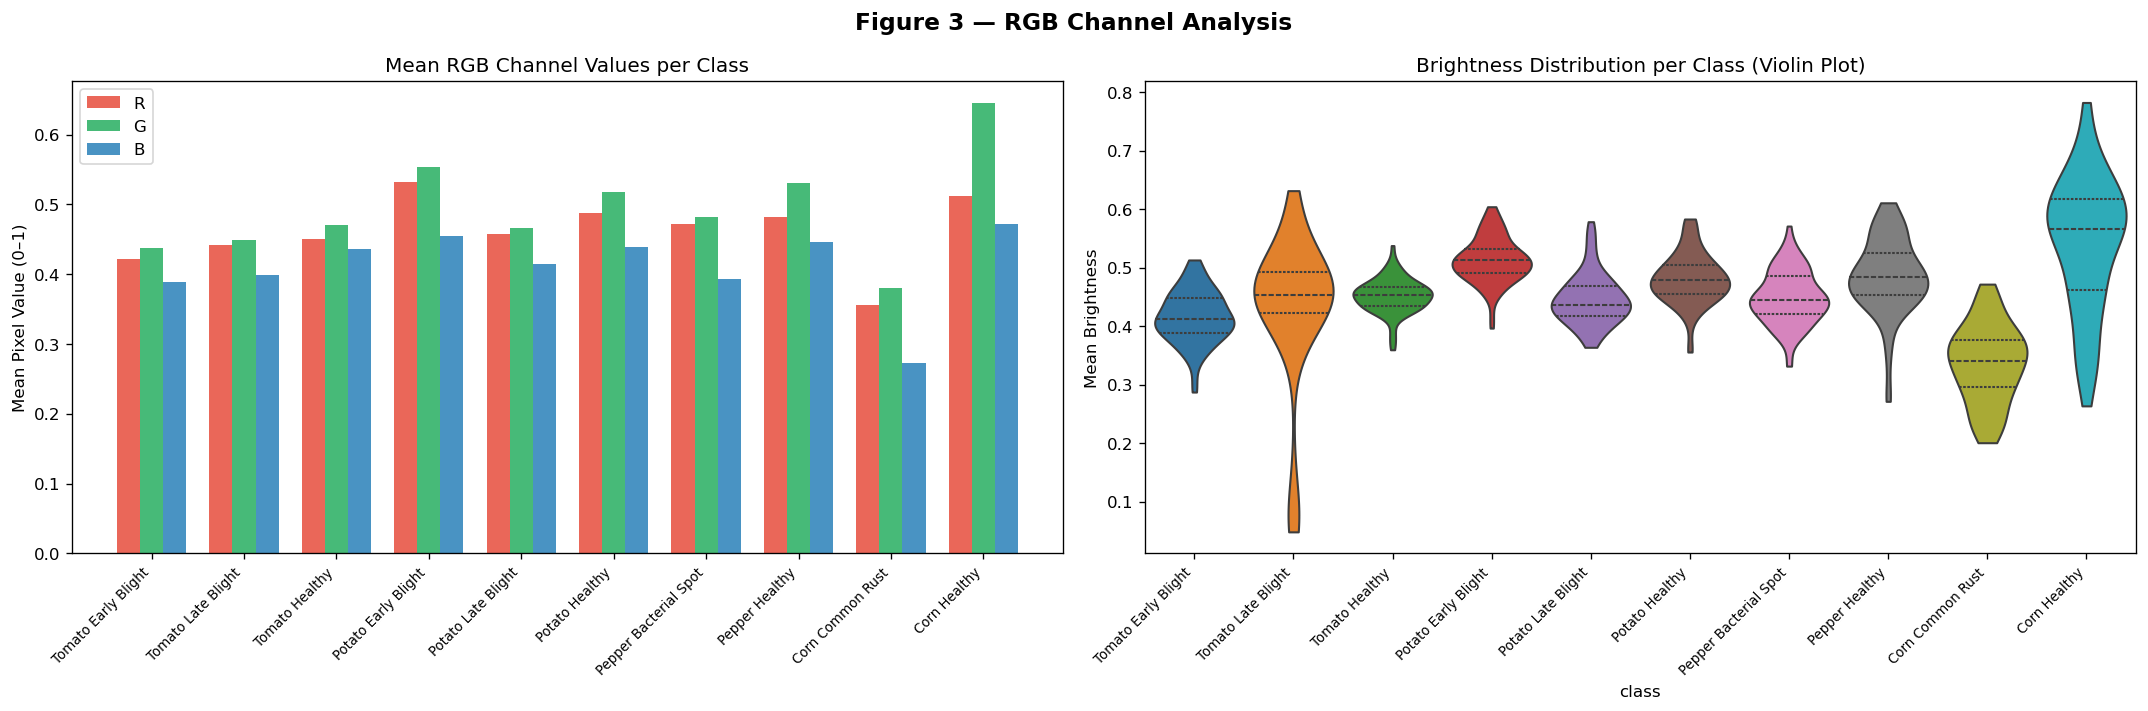

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Figure 3 — RGB Channel Analysis', fontsize=14, fontweight='bold')

x = np.arange(len(CLASS_DISPLAY)); w = 0.25
axes[0].bar(x - w, ch_means['R'], w, label='R', color='#e74c3c', alpha=0.85)
axes[0].bar(x,     ch_means['G'], w, label='G', color='#27ae60', alpha=0.85)
axes[0].bar(x + w, ch_means['B'], w, label='B', color='#2980b9', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_DISPLAY, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Mean Pixel Value (0–1)')
axes[0].set_title('Mean RGB Channel Values per Class')
axes[0].legend()

sns.violinplot(data=ch_df, x='class', y='brightness', ax=axes[1],
               order=CLASS_DISPLAY, palette='tab10', inner='quartile', cut=0)
axes[1].set_xticklabels(CLASS_DISPLAY, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Mean Brightness')
axes[1].set_title('Brightness Distribution per Class (Violin Plot)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig3_channel_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. PCA & t-SNE Feature Space Visualisation

In [9]:
vis_X, vis_y = [], []
print('Loading images for PCA/t-SNE...')
for label, (cls_name, disp) in enumerate(zip(TARGET_CLASSES, CLASS_DISPLAY)):
    cls_rows = df_clean[df_clean['class'] == cls_name]
    sample_df = cls_rows.sample(min(N_VIS, len(cls_rows)), random_state=SEED)
    for path in tqdm(sample_df['path'], desc=disp, leave=False):
        try:
            img = np.array(
                Image.open(path).convert('RGB').resize((MLP_SIZE, MLP_SIZE)),
                dtype=np.float32
            ) / 255.0
            vis_X.append(img.flatten())
            vis_y.append(label)
        except Exception:
            pass

vis_X = np.array(vis_X); vis_y = np.array(vis_y)
print(f'Feature matrix: {vis_X.shape}')

scaler   = StandardScaler()
vis_Xs   = scaler.fit_transform(vis_X)
pca_full = PCA(random_state=SEED).fit(vis_Xs)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)

pca50   = PCA(n_components=PCA_N, random_state=SEED)
vis_Xp  = pca50.fit_transform(vis_Xs)
var50   = pca50.explained_variance_ratio_.sum() * 100
print(f'PCA-{PCA_N} variance retained: {var50:.1f}%')

print('Running t-SNE (may take 1–2 min)...')
tsne   = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=SEED)
vis_Xt = tsne.fit_transform(vis_Xp)
print('t-SNE complete.')

Loading images for PCA/t-SNE...


Feature matrix: (1200, 3072)
PCA-50 variance retained: 82.6%
Running t-SNE (may take 1–2 min)...


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Figure 4 — PCA & t-SNE Feature Space Visualisation',
             fontsize=14, fontweight='bold')

for lbl, disp, col in zip(range(10), CLASS_DISPLAY, PALETTE):
    mask = vis_y == lbl
    axes[0].scatter(vis_Xt[mask, 0], vis_Xt[mask, 1],
                    c=[col], label=disp, alpha=0.65, s=18, edgecolors='none')
axes[0].set_title(f't-SNE 2D Projection (PCA-{PCA_N} features, {var50:.1f}% var)')
axes[0].set_xlabel('t-SNE Dim 1'); axes[0].set_ylabel('t-SNE Dim 2')
axes[0].legend(fontsize=7, markerscale=1.5, loc='upper right')

axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, color='#2980b9', linewidth=2)
axes[1].axvline(PCA_N, color='red', linestyle='--', linewidth=1.5,
                label=f'n={PCA_N} → {var50:.1f}% variance')
axes[1].axhline(var50, color='red', linestyle=':', linewidth=1.2)
axes[1].fill_between(range(1, PCA_N + 1), cumvar[:PCA_N] * 100,
                     alpha=0.15, color='#e74c3c')
axes[1].set_xlabel('Number of PCA Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('PCA Cumulative Variance Curve')
axes[1].set_xlim(1, min(200, len(cumvar)))
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig4_pca_tsne.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
print('=' * 60)
print('  EDA SUMMARY')
print('=' * 60)
print(f'  Total images       : {total:,}')
print(f'  After quality filter: {len(df_clean):,}')
print(f'  Imbalance ratio    : {imbalance:.1f}×')
print(f'  PCA-{PCA_N} variance   : {var50:.1f}%')
print(f'  Minority class     : Potato Healthy ({class_counts.min():,} images)')
print()
print('  Saved figures to', OUT_DIR)
print('  → Proceed to 02_MLP_Baseline.ipynb')